Task 1: Dataset Understanding

In [1]:
# Dataset directory check

import os

data_dir = "dataset"

if not os.path.exists(data_dir):
    print("Dataset folder not found!")
    print("Please download dataset from the link in README and place it in the project directory.")
else:
    print("Dataset found. Proceeding...")

Dataset found. Proceeding...


In [3]:
# Step 1: Load Dataset

import pandas as pd

df = pd.read_csv("dataset/customer_churn_nn.csv")
df.head()


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [47]:
# Step 2: Number of Rows & Columns
print(df.shape, "\n")

# Step 3: Data Types & Structure
df.info()

(2000, 17) 

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  d

In [48]:
# Step 4: Target Variable Analysis
print(df['churn'].value_counts())
print(df['churn'].value_counts(normalize=True) * 100)

# Step 5: Missing Values Check
df.isnull().sum()

churn
0    1969
1      31
Name: count, dtype: int64
churn
0    98.45
1     1.55
Name: proportion, dtype: float64


customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

In [49]:
# Step 6: Statistical Summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


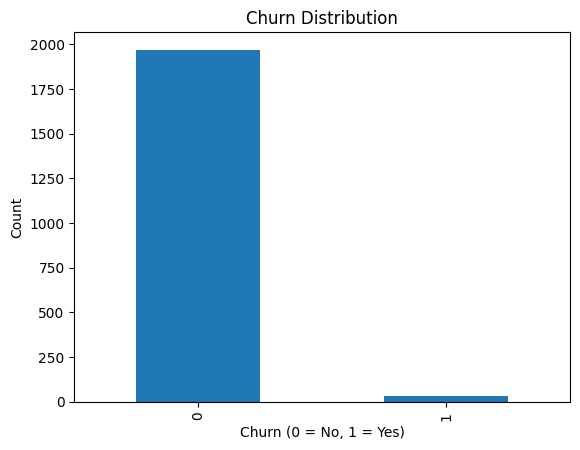

In [50]:
# Step 7: Target Distribution Visualization
import matplotlib.pyplot as plt

df['churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

Task 2: Data Preprocessing

In [51]:
# Handling missing values, if any

# Drop Irrelevant Column
df = df.drop(columns=['customer_id'])

df.isnull().sum()

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Categorical columns
cat_cols = df.select_dtypes(include=['object', 'string']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")


In [57]:
# Encoding categorical columns, if present

df = pd.get_dummies(df, drop_first=True)
print(df.head())


   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                             3                   1          82.17   
2                             0                  11          89.39   
3                             2                   3         139.73   
4                             2                   6         156.43   

   satisfaction_score  last_complaint_days_ago  discount_percent  \
0                 8.0                       67                 0   
1                 5.7                   

In [58]:
# Splitting the dataset into training and testing set

X = df.drop('churn', axis=1)
y = df['churn']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600, 24)
X_test shape: (400, 24)
y_train shape: (1600,)
y_test shape: (400,)


In [62]:
# Scaling or normalizing numerical features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Mean: \n", X_train.mean(axis=0))
print("Standard Deviation: \n", X_train.std(axis=0))

print("Sample scaled data:\n", X_train[:5])

Mean: 
 [-2.22044605e-17 -1.44328993e-17 -1.77635684e-17 -4.44089210e-18
 -9.99200722e-18  2.22044605e-18  7.77156117e-18 -1.55431223e-17
 -1.77635684e-17 -3.33066907e-18 -1.99840144e-17 -2.22044605e-17
  1.33226763e-17 -5.66213743e-17 -1.44328993e-17  0.00000000e+00
 -8.88178420e-18 -5.55111512e-19 -4.55191440e-17  8.88178420e-18
  8.88178420e-18 -8.88178420e-18 -4.44089210e-17  1.11022302e-17]
Standard Deviation: 
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Sample scaled data:
 [[ 0.55152661 -1.20962203 -0.77311873  0.03903991  1.66580806 -0.28259735
   0.08751258 -0.55758798 -1.08497131 -1.21050869 -0.88397962 -0.50682692
   2.13437475 -0.50097637 -0.51752183 -0.31087222 -0.531085   -0.74695096
   1.52299116 -0.40869471 -0.50877431  2.0902458  -0.50097637 -0.50877431]
 [ 0.76521034  0.12074549 -0.95932828 -1.33379204 -0.39531743 -0.79178383
  -0.307281    0.89437184 -0.42315122 -1.21050869  0.08542915  1.97306015
  -0.46852129 -0.50097637 -0.51752183 -

In [64]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Task 3: Neural Network Model Building

In [70]:
# Input Layer
print("Shape of X_train:", X_train.shape)

# Build Model
model = keras.Sequential([
    
    # Explicit Input Layer
    keras.Input(shape=(X_train.shape[1],)),
    
    # Hidden Layers
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    
    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

model.summary()

# Compile module
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Shape of X_train: (1600, 24)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3789 - loss: 0.8209 - val_accuracy: 0.6812 - val_loss: 0.6634
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8367 - loss: 0.5753 - val_accuracy: 0.9563 - val_loss: 0.4774
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9742 - loss: 0.3906 - val_accuracy: 0.9781 - val_loss: 0.3220
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.2458 - val_accuracy: 0.9781 - val_loss: 0.2208
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1615 - val_accuracy: 0.9781 - val_loss: 0.1699
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1205 - val_accuracy: 0.9781 - val_loss: 0.1447
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0993 - val_accuracy: 0.9781 - val_loss: 0.1312
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0876 - val_accuracy: 0.9781 - val_loss:

In [85]:
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

# Make Prediction
y_pred = model.predict(X_test)

print("\nSample predictions:\n", y_pred[:5])

# Convert Probabilities to Classes
y_pred_classes = (y_pred > 0.5).astype(int)

print("\nPredicted classes:\n", y_pred_classes[:5])



13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9825 - loss: 0.0725  

Test Loss: 0.07247187197208405
Test Accuracy: 0.9825000166893005
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Sample predictions:
 [[0.00042713]
 [0.01823649]
 [0.00287784]
 [0.02220885]
 [0.00198297]]

Predicted classes:
 [[0]
 [0]
 [0]
 [0]
 [0]]


#Task 4: Training and Evaluation

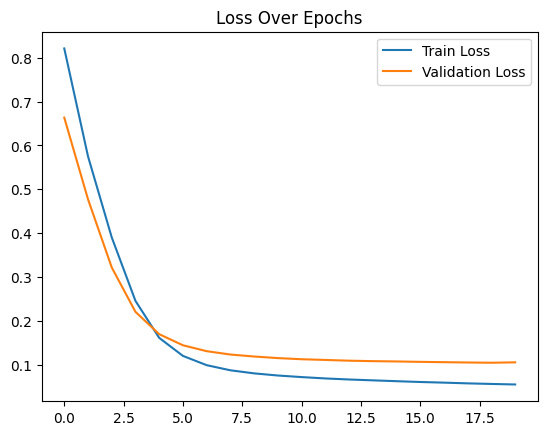

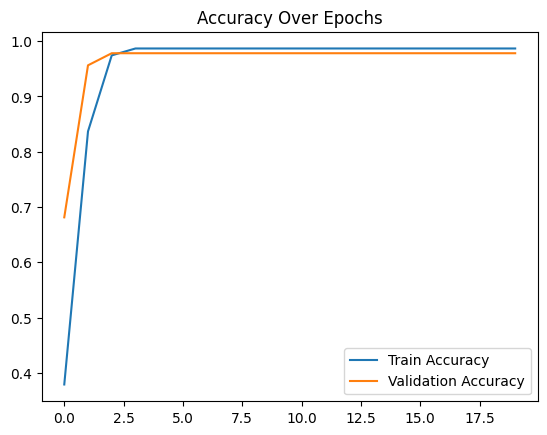

In [76]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Over Epochs")
plt.show()

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Over Epochs")
plt.show()

In [77]:
# Test Evaluation

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9825 - loss: 0.0725  
Test Loss: 0.07247187197208405
Test Accuracy: 0.9825000166893005


Confusion Matrix:
 [[393   0]
 [  7   0]]


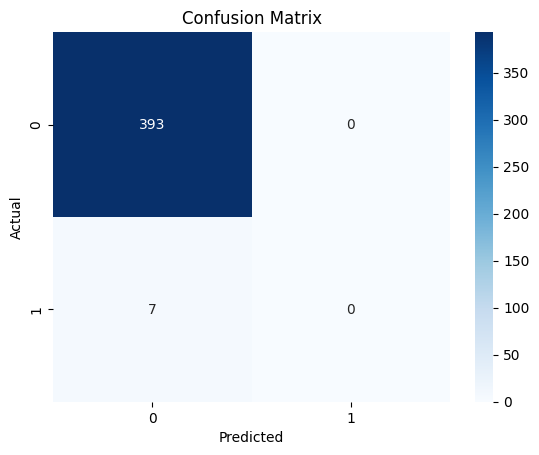

In [ ]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Task 5: Hyperparameter Experimentation

In [79]:
# Reusaable func

def build_and_train_model(neurons=16, learning_rate=0.001, epochs=20):
    
    from tensorflow import keras
    from tensorflow.keras import layers
    
    model = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        layers.Dense(neurons, activation='relu'),
        layers.Dense(8, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    return accuracy, loss


In [80]:
# Run experiments

results = []

# Experiment 1 (Baseline)
acc1, loss1 = build_and_train_model(neurons=16, learning_rate=0.001, epochs=20)
results.append(["Baseline", 16, 0.001, 20, acc1, loss1])

# Experiment 2 (More neurons)
acc2, loss2 = build_and_train_model(neurons=32, learning_rate=0.001, epochs=20)
results.append(["More Neurons", 32, 0.001, 20, acc2, loss2])

# Experiment 3 (Higher learning rate)
acc3, loss3 = build_and_train_model(neurons=16, learning_rate=0.01, epochs=20)
results.append(["Higher LR", 16, 0.01, 20, acc3, loss3])

# Experiment 4 (More epochs)
acc4, loss4 = build_and_train_model(neurons=16, learning_rate=0.001, epochs=40)
results.append(["More Epochs", 16, 0.001, 40, acc4, loss4])

In [84]:
# Create comparison Table
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Experiment", "Neurons", "Learning Rate", "Epochs", "Accuracy", "Loss"
])

print(results_df)

results_df.to_csv("results/model_comparison_table.csv", index=False)

     Experiment  Neurons  Learning Rate  Epochs  Accuracy      Loss
0      Baseline       16          0.001      20    0.9825  0.080874
1  More Neurons       32          0.001      20    0.9825  0.075603
2     Higher LR       16          0.010      20    0.9825  0.250132
3   More Epochs       16          0.001      40    0.9875  0.064639


Task 6: Final Reflection (Use This Directly)
-- Role of Weights and Biases:
Weights and biases are the core parameters of a neural network that get updated during training.

Weights determine the importance of each input feature in making predictions.
Biases allow the model to shift the output, helping it fit the data more accurately.

Together, they control how input data is transformed as it passes through the network. During training, the model adjusts weights and biases to minimize prediction error.

-- Why Activation Function is Required
Activation functions introduce non-linearity into the model.

Without activation functions:

The neural network would behave like a simple linear model
It would not be able to learn complex patterns

Functions like ReLU help hidden layers learn complex relationships, while Sigmoid in the output layer converts predictions into probabilities between 0 and 1.

-- Effect of Learning Rate
The learning rate controls how quickly the model updates its weights.

If the learning rate is too high:
The model may overshoot optimal values
Training becomes unstable
Loss may fluctuate or increase
If the learning rate is too low:
Training becomes very slow
Model may get stuck and not learn effectively

A balanced learning rate helps the model converge efficiently.

-- Underfitting vs Overfitting
In this model:

The training and testing accuracy were both high (~98%), which suggests the model learned patterns effectively.
However, the model failed to predict the minority class (churn cases).

This indicates that:

The model is not overfitting, as performance is similar on training and test data.
It is also not underfitting, as it captures general patterns well.

However, the model suffers from class imbalance, leading to biased predictions toward the majority class.


“Overall, while the model performs well in terms of accuracy, improving class balance and evaluation metrics is necessary for real-world applicability.”